In [23]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os

os.makedirs('../figures', exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')

In [24]:
with open('../results/results.json') as f:
    store = json.load(f)

print('Meta:', store['meta'])
print('Datasets available:', list(store['datasets'].keys()))

Meta: {'n_splits': 10, 'test_size': 0.2, 'seed': 0, 't_grid_points': 200, 'tabpfn_train_max': 1000, 'tabpfn_batch': 164}
Datasets available: ['whas500', 'gbsg', 'metabric']


In [25]:
# Flatten into a tidy DataFrame
records = []
for ds, methods in store['datasets'].items():
    for method, splits in methods.items():
        for s in splits:
            records.append({'dataset': ds, 'method': method,
                            'C-index': s['ci'], 'IBS': s['ibs']})

df = pd.DataFrame(records)
datasets = list(store['datasets'].keys())
methods  = df['method'].unique().tolist()
print(df.groupby(['dataset', 'method'])[['C-index', 'IBS']].mean().round(3))

                     C-index    IBS
dataset  method                    
gbsg     bin_fsa       0.673  0.190
         cox           0.661  0.190
         fsa           0.656  0.272
         lognormal     0.669  0.188
         pseudo_fsa    0.665  0.185
         rsf           0.677  0.185
         weibull       0.662  0.191
metabric bin_fsa       0.642  0.184
         cox           0.643  0.185
         fsa           0.619  0.229
         lognormal     0.646  0.187
         pseudo_fsa    0.649  0.186
         rsf           0.624  0.190
         weibull       0.643  0.185
whas500  bin_fsa       0.779  0.166
         cox           0.768  0.168
         fsa           0.699  0.311
         lognormal     0.767  0.171
         pseudo_fsa    0.758  0.160
         rsf           0.745  0.162
         weibull       0.769  0.169


In [26]:
METHOD_LABELS = {
    'fsa':        'FSA (ours)',
    'bin_fsa':    'FSA Binned (ours)',
    'pseudo_fsa': 'FSA Pseudo-obs (ours)',
    'cox':        'Cox PH',
    'weibull':    'Weibull AFT',
    'lognormal':  'LogNormal AFT',
    'rsf':        'RSF',
}
PALETTE = dict(zip(
    METHOD_LABELS.keys(),
    ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#999999', '#f781bf']
))

df['Method'] = df['method'].map(METHOD_LABELS)
method_order = [METHOD_LABELS[m] for m in METHOD_LABELS]
color_order  = [PALETTE[m] for m in METHOD_LABELS]

/var/folders/h1/f9pg300n4ms2xmrzzl99521w0000gn/T/ipykernel_4880/940503581.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/h1/f9pg300n4ms2xmrzzl99521w0000gn/T/ipykernel_4880/940503581.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(method_order, rotation=35, ha='right', fontsize=9)
/var/folders/h1/f9pg300n4ms2xmrzzl99521w0000gn/T/ipykernel_4880/940503581.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/h1/f9pg300n4ms2xmrzzl99521w0000gn/T/ipykernel_4880/940503581.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, 

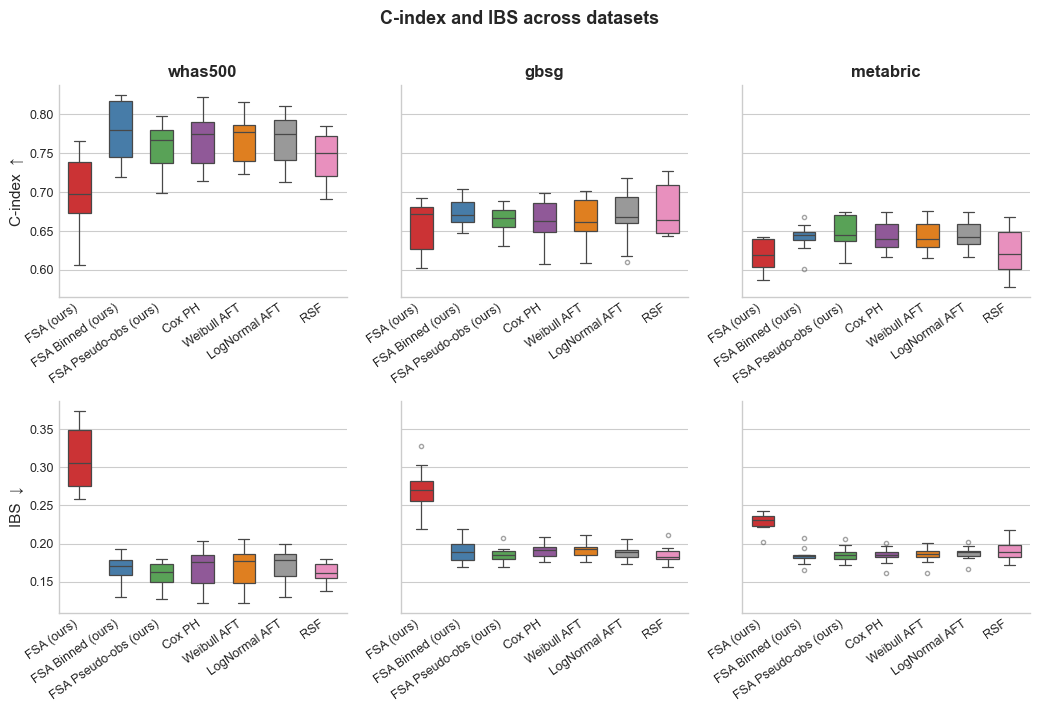

In [27]:
n_ds = len(datasets)
fig, axes = plt.subplots(2, n_ds, figsize=(3.5 * n_ds, 7), sharey='row')
if n_ds == 1:
    axes = axes.reshape(2, 1)

for col, ds in enumerate(datasets):
    sub = df[df['dataset'] == ds]
    for row, (metric, better) in enumerate([('C-index', '↑'), ('IBS', '↓')]):
        ax = axes[row, col]
        sns.boxplot(
            data=sub, x='Method', y=metric, order=method_order,
            palette=color_order, width=0.55, linewidth=0.9,
            flierprops=dict(marker='o', markersize=3, alpha=0.5),
            ax=ax
        )
        if row == 0:
            ax.set_title(ds, fontsize=12, fontweight='bold', pad=6)
        ax.set_xlabel('')
        ax.set_xticklabels(method_order, rotation=35, ha='right', fontsize=9)
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
        ax.tick_params(axis='y', labelsize=9)
        if col == 0:
            ax.set_ylabel(f'{metric}  {better}', fontsize=11)
        else:
            ax.set_ylabel('')
        ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('C-index and IBS across datasets', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/results_boxplots.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../figures/results_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Summary table: mean ± std
rows = []
for ds in datasets:
    for method in METHOD_LABELS:
        sub = df[(df['dataset'] == ds) & (df['method'] == method)]
        if sub.empty:
            continue
        rows.append({
            'Dataset': ds, 'Method': METHOD_LABELS[method],
            'C-index': f"{sub['C-index'].mean():.3f} ± {sub['C-index'].std():.3f}",
            'IBS':     f"{sub['IBS'].mean():.3f} ± {sub['IBS'].std():.3f}",
        })

table = pd.DataFrame(rows).set_index(['Dataset', 'Method'])
display(table)
print('\nLaTeX:')
print(table.to_latex())